In [1]:
# Import all the libraries we need
# KMeans is the clustering algorithm
# seaborn is for making prettier graphs
# StandardScaler brings all features to the same scale
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load the churn dataset
df = pd.read_csv('churn-bigml-80.csv')

# Drop columns that wont help with clustering
# State has too many unique values
# Churn is what we would normally predict but in clustering we dont use labels
df = df.drop(['State', 'Churn'], axis=1)

# Convert text columns to numbers
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['International plan'] = le.fit_transform(df['International plan'])
df['Voice mail plan'] = le.fit_transform(df['Voice mail plan'])

print("Dataset loaded and cleaned!")
print("Shape:", df.shape)
print()
print(df.head())

Dataset loaded and cleaned!
Shape: (2666, 18)

   Account length  Area code  International plan  Voice mail plan  \
0             128        415                   0                1   
1             107        415                   0                1   
2             137        415                   0                0   
3              84        408                   1                0   
4              75        415                   1                0   

   Number vmail messages  Total day minutes  Total day calls  \
0                     25              265.1              110   
1                     26              161.6              123   
2                      0              243.4              114   
3                      0              299.4               71   
4                      0              166.7              113   

   Total day charge  Total eve minutes  Total eve calls  Total eve charge  \
0             45.07              197.4               99             16.78   

In [3]:
# scaling the data before clustering
# k-means measures distance between points so big numbers would throw it off
# basically making sure everything is on a fair playing field

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

print("scaled!")
print("shape:", X_scaled.shape)

scaled!
shape: (2666, 18)


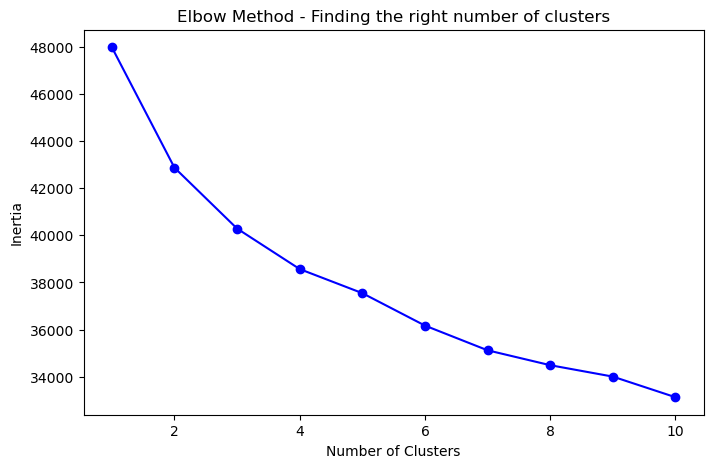

In [4]:
# figuring out how many clusters to use
# elbow method runs k-means multiple times with different numbers of clusters
# method also measures how tight the clusters are each time
# where the graph bends like an elbow is usually the sweet spot

inertia = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# plot the results
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, marker='o', color='blue')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method - Finding the right number of clusters')
plt.show()

In [5]:
# based on the elbow graph, 3 clusters looks like a good choice
# the curve starts flattening out around there

kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# see how many customers ended up in each cluster
print("customers per cluster:")
print(df['Cluster'].value_counts())

customers per cluster:
Cluster
1    974
0    963
2    729
Name: count, dtype: int64


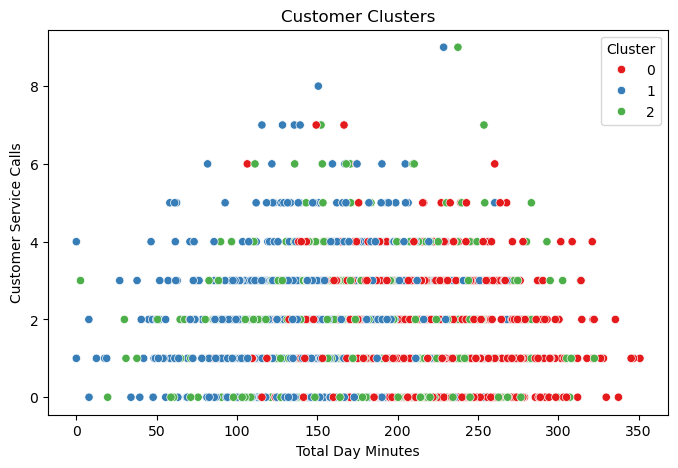

In [6]:
# visualising the clusters using 2 features
# we cant plot 18 dimensions so we just pick 2 interesting ones to show on a graph
# total day minutes vs customer service calls is a good combo

plt.figure(figsize=(8, 5))
sns.scatterplot(x=df['Total day minutes'], 
                y=df['Customer service calls'],
                hue=df['Cluster'], 
                palette='Set1')

plt.title('Customer Clusters')
plt.xlabel('Total Day Minutes')
plt.ylabel('Customer Service Calls')
plt.show()

In [7]:
# look at the average values for each group to see what makes each cluster different

cluster_summary = df.groupby('Cluster')[['Total day minutes', 
                                          'Customer service calls',
                                          'Total day charge',
                                          'International plan']].mean().round(2)

print("Average values per cluster:")
print(cluster_summary)

Average values per cluster:
         Total day minutes  Customer service calls  Total day charge  \
Cluster                                                                
0                   211.26                    1.44             35.92   
1                   146.93                    1.72             24.98   
2                   180.99                    1.52             30.77   

         International plan  
Cluster                      
0                      0.11  
1                      0.09  
2                      0.10  


In [8]:
# interpreting what each cluster means in plain english based on the averages we can give each group a label

print("Cluster Interpretation:")
print()
print("Cluster 0 - HIGH VALUE CUSTOMERS")
print("  - Highest day minutes (211) and highest charges (35.92)")
print("  - These are heavy users who spend the most")
print("  - Company should keep these customers happy!")
print()
print("Cluster 1 - LOW USAGE CUSTOMERS")
print("  - Lowest day minutes (146) and lowest charges (24.98)")
print("  - Light users who don't use the service much")
print("  - Could be targeted with promotions to increase usage")
print()
print("Cluster 2 - AVERAGE CUSTOMERS")
print("  - Middle ground on everything")
print("  - Average usage and average spending")
print("  - The typical everyday customer")

Cluster Interpretation:

Cluster 0 - HIGH VALUE CUSTOMERS
  - Highest day minutes (211) and highest charges (35.92)
  - These are heavy users who spend the most
  - Company should keep these customers happy!

Cluster 1 - LOW USAGE CUSTOMERS
  - Lowest day minutes (146) and lowest charges (24.98)
  - Light users who don't use the service much
  - Could be targeted with promotions to increase usage

Cluster 2 - AVERAGE CUSTOMERS
  - Middle ground on everything
  - Average usage and average spending
  - The typical everyday customer
